<img src="https://dootoo.app/images/thoughtswork_banner.png"/>

# Kaggle Competition Submission: Titanic Passenger Survival Classification

* **Author:** Paul Tongyoo
* **Contact:** Message me on <a href="https://www.linkedin.com/in/paultongyoo/">LinkedIn</a>
* **Date:** June 17, 2025
* **Official Competition Page:** <a href="https://www.kaggle.com/competitions/titanic">Titanic: Machine Learning from Disaster</a>
* **Best Submission Score (Accuracy):** TBD

## Table of Contents

1. [Project Summary](#Project-Summary)
    1. [What I Did](#What-I-Did)
    1. [What I Learned](#What-I-Learned)
    1. [Next Steps](#Next-Steps)
1. [Problem Context](#Problem-Context)
1. [Source Data](#Source-Data)
    1. [Data Dictionary](#Data-Dictionary)
    1. [Variable Notes](#Variable-Notes)
1. [Model Development Strategy](#Model-Development-Strategy)
    1. [Data Sets](#Data-Sets)
    1. [Five Stage Process](#Five-Stage-Process)
    1. [Metrics Strategy](#Metrics-Strategy)
1. [Implementation](#Implementation)
    1. [Descriptive Statistics](#Descriptive-Statistics)
    1. [Data Types](#Data-Types)
    1. [Missing Values Summary](#Missing-Values-Summary)
    1. [Visual Inspection Insights](#Visual-Inspection-Insights)
    1. [Exploratory Data Analysis](#Exploratory-Data-Analysis)
        1. [Survived (Target)](#Survived-Target)
        1. [Age](#Age)
        1. [Fare](#Fare)
        1. [Deck](#Deck)
        1. [Family Size](#Family-Size)
        1. [Sex vs Is Alone](#Sex-vs-Is-Alone)
    1. [Feature Engineering](#Feature-Engineering)
        1. [Feature Creation](#Feature-Creation)
        1. [Pipeline Imputers](#Pipeline-Imputers)
    1. [Model Development](#Model-Development)
        1. [Training Set Evaluation](#Training-Set-Evaluation)
        1. [Training Set Prediction Mistake Analysis](#Training-Set-Prediction-Mistake-Analysis)
            1. [Correct vs Mistake Feature Distribution Comparison](#Correct-vs-Mistake-Feature-Distribution-Comparison)
            1. [Feature Predictiveness of Mistakes](#Feature-Predictiveness-of-Mistakes)
        1. [Dev Set Evaluation](#Dev-Set-Evaluation)
        1. [Grid Search Cross-Validation Evaluation](#Grid-Search-Cross-Validation-Evaluation)
        1. [Evaluation Summary](#Evaluation-Summary)
    1. [Submission File Generation](#Submission-File-Generation)

## Project Summary

In [1]:
# TODO Complete after project is finished

### What I Did

In [2]:
# TODO

### What I Learned

In [3]:
# TODO

### Next Steps

In [4]:
# TODO

## Problem Context

The sinking of the Titanic is one of the most infamous shipwrecks in history.

On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone onboard, resulting in the death of 1502 out of 2224 passengers and crew.

While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others.

In this challenge, Kaggle asked us to build a predictive model that answers the question: **“What sorts of people were more likely to survive?”** using passenger data (e.g. name, age, gender, socio-economic class, etc).

## Source Data

Kaggle provided passenger data split into two files:
* "Training Set" (<a href="./input/train.csv">train.csv</a>)
    * 891 rows, 12 features
* "Test Set" (<a href="./input/test.csv">test.csv</a>)
    * 418 rows, 11 features (no `Survived` col)

### Data Dictionary

| Variable | Definition | Key, Example |
| -------- | ---------- | --- |
| **Survived** (target) | Survival | 0 = No, 1 = Yes |
| **PassengerId** | Integer index of passenger | 0,1,2,3,... |
| **Name** | Name of passenger including title | Braund, Mr. Owen Harris |
| **Pclass** | Ticket class | 1 = 1st, 2 = 2nd, 3 = 3rd |
| **Sex** | Sex | female, male |
| **Age** | Age in years | 0.15, 2, 15 |
| **SibSp** | # of siblings / spouses aboard the Titanic | 0,1,2,3,.. |
| **Parch** | # of parents / children aboard the Titanic | 0,1,2,3,.. |
| **Ticket** | Ticket number, some with prefixes, **shared among groups** | SW/PP 751 |
| **Fare** | Passenger fare, **shared among groups**	 | 7.91, 14.4542, 512.3292 |
| **Cabin** | Cabin number(s) listed on ticket, prefixed with deck letter, **shared among groups**	 | A20, "B57 B59 B63 B66"	 |
| **Embarked** | Port of Embarkation | C = Cherbourg (France), Q = Queenstown (Ireland), S = Southampton (England) |

### Variable Notes

**pclass:** A proxy for socio-economic status (SES)
* 1st = Upper
* 2nd = Middle
* 3rd = Lower

**age:** Age is fractional if less than 1. If the age is estimated, is it in the form of xx.5

**sibsp:** The dataset defines family relations in this way...
* Sibling = brother, sister, stepbrother, stepsister
* Spouse = husband, wife (mistresses and fiancés were ignored)

**parch:** The dataset defines family relations in this way...
* Parent = mother, father
* Child = daughter, son, stepdaughter, stepson
* Some children travelled only with a nanny, therefore parch=0 for them.

## Model Development Strategy

### Data Sets


The Training Set will be split into two data sets:
* `X_train, y_train` (80%)
* `X_dev, y_dev` (20%)

The Test Set will be maintained as a single data set:
* `X_test` (100%)


### Five Stage Process


Model development follows a five-stage process to optimize bias, variance, and generalization to the test set:
* **Stage 1: Bias Optimization**
    * Uses only `X_train, y_train`.
    * Used to evaluate model bias only (not variance) using `model.predict(X_train)`.
    * Diagnostic fits done at this stage to identify high-bias model types and features to avoid and/or optimize in Stage 2.
* **Stage 2: Generalization Optimization**: 
    * Uses only `X_train, y_train`.
    * Cross-validation performed to assess model generalization performance across CV loops
        * Provides some bias/variance insights by comparing performance across loops.
        * Final variance checks against single holdout distribution will be possible in Stage 3.
    * Final model selection, feature engineering, and hyperparameter tuning done in this stage.
    * CV stratification will be limited to label-based stratification only to start.
        * If the model generalizes poorly to `X_test` compared to `X_dev` (e.g., error gap > 2 pp), Stage 5: Distribution Alignment will be triggered to investigate covariate shift.
* **Stage 3: Final Generalization Evaluation**
    * Uses only `X_dev, y_dev`.
    * Model evaluated using truly unseen data.
    * Used to evaluate model variance by comparing scores with scores obtained during Stage 2.
    * If model variance exceeds `2 pp`, return to Stage 2 or 1 to iterate on model hyperparameters, features, and/or model type.
* **Stage 4: Submission Evaluation**
    * `X_train, y_train` and `X_dev, y_dev` sets will be combined into `X_train_full, y_train_full`.
    * Model will be retrained on `X_train_full`.
    * Model is then used to predict labels on `X_test`.
    * Labeled `X_test` is submitted to Kaggle's site for accuracy scoring.
    * If generalization error between `X_train_full` and `X_test` is exceeds `2 pp` than `X_train_full`/`X_dev` generalization error, proceed to Stage 5.
* **Stage 5: Train/Test Set Distribution Alignment**
    * A **discriminator classifier** will be trained and evaluated to learn if the classifier is able to distinguish between the processed `X_train_full` and `X_test` rows (`P(Row is a X_test row = 1)`).
        * If `ROC AUC ≤ 0.52`:
            * The sets are likely distributionally identical.
            * No sample reweighting will be applied and further investigation will be conducted.
        * If `ROC AUC > 0.52`:
            * The sets differ.
            * Sample reweighting will increase the weight of training samples resembling test set rows.
            * Repeat Stage 4 with new sample weights and compare new generalization scores.

Evaluation metrics (Log Loss, ROC AUC, PR AUC, etc.) are detailed in the [Metrics Strategy](#metrics-strategy) section and used consistently across all stages.

### Metrics Strategy

* Due to imbalanced survival rate (vast majority perished), metrics that measure accurate prediction of the minority positive class will be prioritized.
* The following metrics will be used to evaluate each stage of model development, in priority order:
    * Log loss
    * ROC AUC
    * PR AUC
    * F1 score
        * Precision
        * Recall
    * Accuracy



## Implementation

In [5]:
from datetime import datetime
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import chi2_contingency, ks_2samp

import mlflow
import warnings
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message=".*Inferred schema contains integer column.*",
    module="mlflow\\.types\\.utils"
)

from sklearn.utils.validation import check_is_fitted
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate, learning_curve, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, log_loss, make_scorer, roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin, clone
from sklearn.preprocessing import FunctionTransformer, LabelEncoder, StandardScaler, OneHotEncoder, KBinsDiscretizer
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, FeatureUnion
import shap



In [6]:
training_set_df = pd.read_csv('./input/train.csv')
target = 'Survived'

# Training Set (with labels)
X_train = training_set_df.drop(columns=target)
y_train = training_set_df[target]

# Kaggle Titanic Submission Test Set (no labels)
X_test = pd.read_csv('./input/test.csv')

# Split the training set into Training and "Dev" (aka "Validation" aka "Holdout") sets
# Training Set is split using label stratification only for now to balance target classes across sets.
# Additional stratification will be explored later if unable to address generalization issues with the current split.
X_train, X_dev, y_train, y_dev = train_test_split(X_train, y_train, stratify=y_train, test_size=0.2, random_state=42)

X_train.shape, y_train.shape, X_dev.shape, y_dev.shape, X_test.shape

((712, 11), (712,), (179, 11), (179,), (418, 11))

### Descriptive Statistics

In [7]:
pd.concat([X_train, y_train], axis=1).describe(include='all')

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
count,712.000000,712.000000,712,712,575.000000,712.000000,712.000000,712,712.000000,160,710,712.000000
unique,NaN,NaN,712,2,NaN,NaN,NaN,571,NaN,127,3,NaN
top,NaN,NaN,"Lam, Mr. Ali",male,NaN,NaN,NaN,1601,NaN,G6,S,NaN
freq,NaN,NaN,1,459,NaN,NaN,NaN,6,NaN,4,516,NaN
mean,444.405899,2.308989,NaN,NaN,29.807687,0.492978,0.390449,NaN,31.819826,NaN,NaN,0.383427
std,257.465527,0.833563,NaN,NaN,14.485211,1.060720,0.838134,NaN,48.059104,NaN,NaN,0.486563
min,1.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN,0.000000
25%,222.750000,2.000000,NaN,NaN,21.000000,0.000000,0.000000,NaN,7.895800,NaN,NaN,0.000000
50%,439.500000,3.000000,NaN,NaN,28.500000,0.000000,0.000000,NaN,14.454200,NaN,NaN,0.000000
75%,667.250000,3.000000,NaN,NaN,39.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN,1.000000


Initial numerical insights:
* **PassengerId:** Column is most likely a sequential integer index from 1 to 891
* **Survived:** Mean survival rate for this data set is 38.3%, imbalance warrants focus on precision/recall of minority positive class
* **Pclass:** Top 25% of passengers were in 1st and 2nd Class, majority 75% in 3rd class
* **Age:** Youngest child was less than 6 months old, oldest is 80 years old.  Median age 28.5 yrs, 75th pecentile 39 yrs.  Contains missing values.
* **SibSp / Parch**:  At least 50% of passengers traveled alone, 75% passengers had at most 1 sibling or spouse.  Max family size is 8
* **Fare:** Fares ranged from 0.00 (potentially crew?) to 512.32.  Median fare 14.45, 75th percentile 31.00 - highest fares likely correlates with upper class

Initial categorical insights:
* **Name:** Contains surname and title info, probable tokens for splitting
* **Sex:** Majority of passengers were male
* **Ticket:** Contains number; some contain prefixes with potentially useful info. 140+ passengers shared the same ticket number, indicating traveling together (may be family and/or household staff)
* **Cabin:** Contains room number and deck letter prefix.  Some cabin strings contain multiple cabin numbers, may also signal family or household staff relationships.  687 values missing
* **Embarked:** Majority of passengers embarked from Southampton, England (644).  2 values missing

### Data Types

In [8]:
pd.concat([X_train, y_train], axis=1).dtypes

PassengerId      int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
Survived         int64
dtype: object

### Missing Values Summary

Missing values to impute across Training and Test Sets:
* Training Set
    * `Age`
    * `Cabin`
    * `Embarked`
* Test Set
    * `Age`
    * `Cabin`
    * `Fare`

In [9]:
print(X_train.isnull().sum().loc[lambda x: x > 0])
print()
print(X_test.isnull().sum().loc[lambda x: x > 0])

Age         137
Cabin       552
Embarked      2
dtype: int64

Age       86
Fare       1
Cabin    327
dtype: int64


### Visual Inspection Insights

* Visual inspection shows variations in **ticket prefixes**, **cabin numbers (e.g. multiple numbers)** and **name tokens (e.g. title, multiple names)**.
* `Fare` is identical amongst passengers with same `Ticket`, suggesting **`Fare` might be shared amongst shared ticket holders.**
* `Name` occassionally contains another name in parenthesis (e.g. `Taussig, Mrs. Emil (Tillie Mandelbaum)`)
* `Ticket` prefixes need cleaning and consolidation (e.g. `W./C.` and `W/C` likely the same)

In [10]:
X_train.sort_values(by="Ticket")

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
257,258,1,"Cherry, Miss. Gladys",female,30.0,0,0,110152,86.500,B77,S
585,586,1,"Taussig, Miss. Ruth",female,18.0,0,2,110413,79.650,E68,S
262,263,1,"Taussig, Mr. Emil",male,52.0,1,1,110413,79.650,E67,S
558,559,1,"Taussig, Mrs. Emil (Tillie Mandelbaum)",female,39.0,1,1,110413,79.650,E67,S
475,476,1,"Clifford, Mr. George Quincy",male,NaN,0,0,110465,52.000,A14,S
...,...,...,...,...,...,...,...,...,...,...,...
736,737,3,"Ford, Mrs. Edward (Margaret Ann Watson)",female,48.0,1,3,W./C. 6608,34.375,NaN,S
147,148,3,"Ford, Miss. Robina Maggie ""Ruby""",female,9.0,2,2,W./C. 6608,34.375,NaN,S
235,236,3,"Harknett, Miss. Alice Phoebe",female,NaN,0,0,W./C. 6609,7.550,NaN,S
219,220,2,"Harris, Mr. Walter",male,30.0,0,0,W/C 14208,10.500,NaN,S


### Exploratory Data Analysis

In [11]:
def numeric_features(X_df, features):
    """
    Returns a list of numeric features from the DataFrame.
    
    Parameters:
    - X_df: DataFrame containing the features
    - features: List of feature names to check
    
    Returns:
    - List of numeric feature names
    """
    return [feature for feature in features if pd.api.types.is_numeric_dtype(X_df[feature])]

In [12]:
def visualize_feature(X_df, feature, y_df=None):
    if y_df is not None:
        df = pd.concat([X_df[feature], y_df], axis=1)
        df.columns = [feature, 'Survived']
    else:
        df = X_df
    plt.figure(figsize=(5, 3))
    if pd.api.types.is_numeric_dtype(X_df[feature]):
        if y_df is not None:
            sns.displot(x=feature, hue='Survived', data=df, bins=30, kde=True)
        else:
            sns.histplot(x=feature, data=df, bins=30, kde=True)
        plt.xlabel(feature)
        plt.title(f'Histogram of {feature} by Survived')
        plt.show()
    else:
        if y_df is not None:
            sns.countplot(x=feature, hue='Survived', data=df)
        else:
            sns.countplot(x=feature, data=df)
        plt.title(f'Countplot of {feature} by Survived')
        plt.show()

#### Survived (Target)

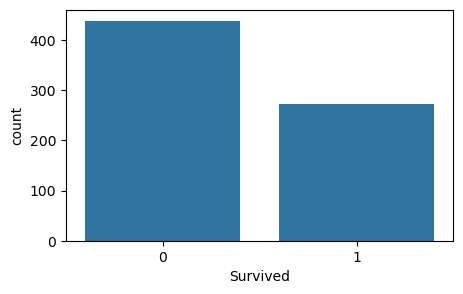

Global Survival Rate: 0.3834
Baseline Accuracy (if predicting majority class): 0.6166


In [13]:
y_df = pd.DataFrame(y_train).reset_index(drop=True)

plt.figure(figsize=(5, 3))
sns.countplot(x='Survived', data=y_df)
plt.show()

global_survival_rate = y_df['Survived'].mean()
print(f"Global Survival Rate: {global_survival_rate:.4f}")
print(f"Baseline Accuracy (if predicting majority class): {max(global_survival_rate, 1 - global_survival_rate):.4f}") 

#### Age

Derived domain-binned 'Age_Bin' feature based on non-linear age-survival relationship.
* Child: 0-10 years
* Teen: 10-17 years
* Young Adult: 17-35 years
* Middle Aged: 35-55 years
* Senior: 55-100 years

<Figure size 500x300 with 0 Axes>

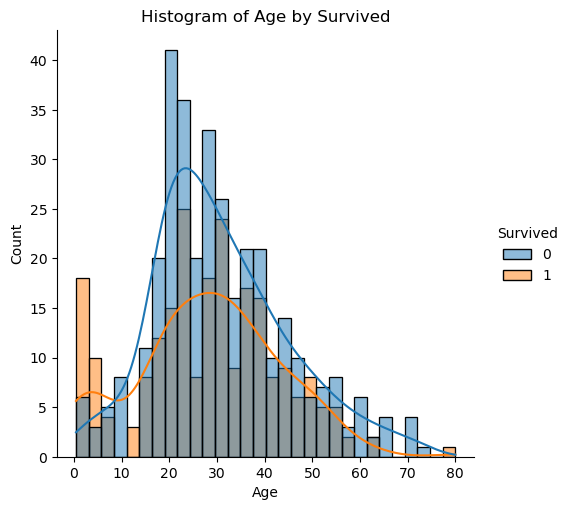

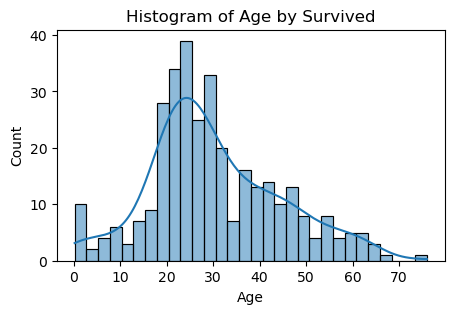

In [14]:
visualize_feature(X_train, 'Age', y_train)
visualize_feature(X_test, 'Age')

#### Fare

<Figure size 500x300 with 0 Axes>

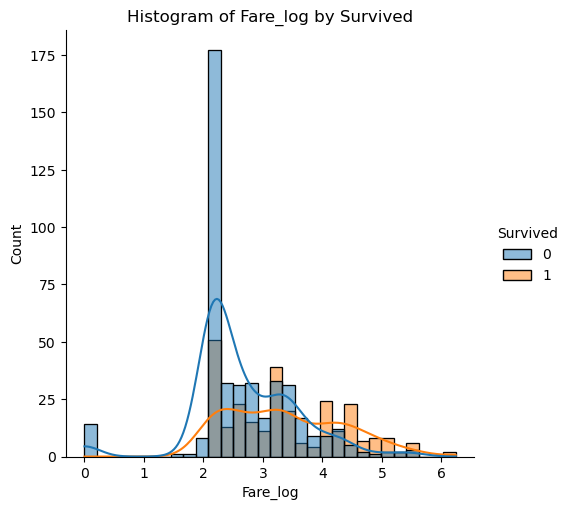

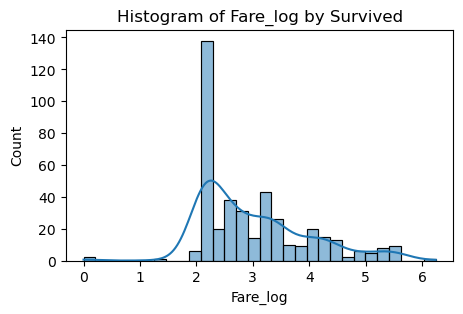

In [15]:
# Make copy of X_train/X_test and take Log1p of Fare to reduce skewness
# Make copy of only Fare column to avoid modifying original DataFrame
X_train_fare = X_train[['Fare']].copy()
X_train_fare['Fare_log'] = np.log1p(X_train_fare)

X_test_fare = X_test[['Fare']].copy()
X_test_fare['Fare_log'] = np.log1p(X_test_fare)

visualize_feature(X_train_fare, 'Fare_log', y_train)
visualize_feature(X_test_fare, 'Fare_log')  

# Ensure this feature is not used in model training directly to prevent data leakage
# log(Fare) must be done within pipeline to constrain calculation to training set only

#### Deck

* Sparse individual deck counts warrant binning to increase potential signal
* Analysis of class distribution across decks yielded the following groups:
    * `ABC`: 1st class only
    * `DE`: 1st class and some 2nd class
    * `Rare` : Lower and rarely occupied decks
    * `Unknown` : Deck letter unassigned

In [16]:
X_train_deck = X_train[['Cabin', 'Pclass']].copy()
X_train_deck['Deck'] = X_train_deck['Cabin'].str[0].fillna('Unknown')
comb_df = pd.concat([X_train_deck, y_train], axis=1)
survival_df = (
    comb_df
    .groupby("Deck", observed=True)
    .agg(
        Survival_Rate=('Survived', 'mean'),
        Count=('Survived', 'size'),
        Pclass_1_Count=('Pclass', lambda x: (x == 1).sum()),
        Pclass_2_Count=('Pclass', lambda x: (x == 2).sum()),
        Pclass_3_Count=('Pclass', lambda x: (x == 3).sum())
    )
    .reset_index()
    .sort_values(by="Deck", ascending=True)
)
survival_df

,Deck,Survival_Rate,Count,Pclass_1_Count,Pclass_2_Count,Pclass_3_Count
0,A,0.428571,14,14,0,0
1,B,0.735294,34,34,0,0
2,C,0.682927,41,41,0,0
3,D,0.807692,26,23,3,0
4,E,0.758621,29,23,4,2
5,F,0.727273,11,0,8,3
6,G,0.500000,4,0,0,4
7,T,0.000000,1,1,0,0
8,Unknown,0.291667,552,35,135,382


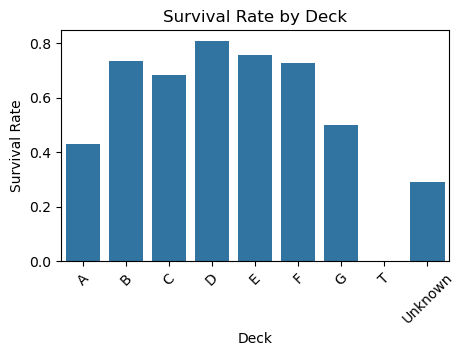

In [17]:
# Plot X_train Deck survival rate
def plot_deck_survival_rate(X_df, y_df):
    """
    Plots the survival rate by Deck.
    
    Parameters:
    - X_df: DataFrame containing the features
    - y_df: Series containing the target values
    """
    if 'Deck' not in X_df.columns:
        print("Deck feature not found in the DataFrame.")
        return
    
    deck_survival = pd.concat([X_df['Deck'], y_df], axis=1)
    deck_survival = deck_survival.groupby('Deck')['Survived'].mean().reset_index()
    
    plt.figure(figsize=(5, 3))
    sns.barplot(x='Deck', y='Survived', data=deck_survival)
    plt.title('Survival Rate by Deck')
    plt.xlabel('Deck')
    plt.ylabel('Survival Rate')
    plt.xticks(rotation=45)
    plt.show()

X_train_deck = X_train[['Cabin']].copy()
X_train_deck['Deck'] = X_train_deck['Cabin'].str[0].fillna('Unknown')
plot_deck_survival_rate(X_train_deck, y_train)

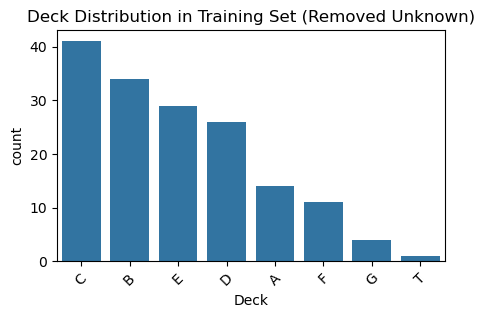

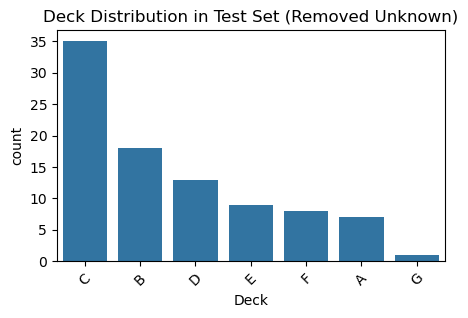

In [18]:
# Plot Train vs Test Deck values
X_train_deck = X_train[['Cabin']].copy()
X_test_deck = X_test[['Cabin']].copy()
X_train_deck['Deck'] = X_train_deck['Cabin'].str[0]
X_test_deck['Deck'] = X_test_deck['Cabin'].str[0]

plt.figure(figsize=(5, 3))
sns.countplot(x='Deck', data=X_train_deck, order=X_train_deck['Deck'].value_counts().index) 
plt.title('Deck Distribution in Training Set (Removed Unknown)')
plt.xticks(rotation=45) 
plt.show()  
plt.figure(figsize=(5, 3))
sns.countplot(x='Deck', data=X_test_deck, order=X_test_deck['Deck'].value_counts().index) 
plt.title('Deck Distribution in Test Set (Removed Unknown)')
plt.xticks(rotation=45) 
plt.show()

#### Family Size

Passenger family sizes have a non-linear relationship with survival:
* More passengers traveling alone perished rather than survived.
* Roughly equal number of passengers traveling with one family member perished and survived.
* More passengers with 2 or 3 family members survived rather than perished.
* Majority of passengers with 4 or more family members perished.

<Figure size 500x300 with 0 Axes>

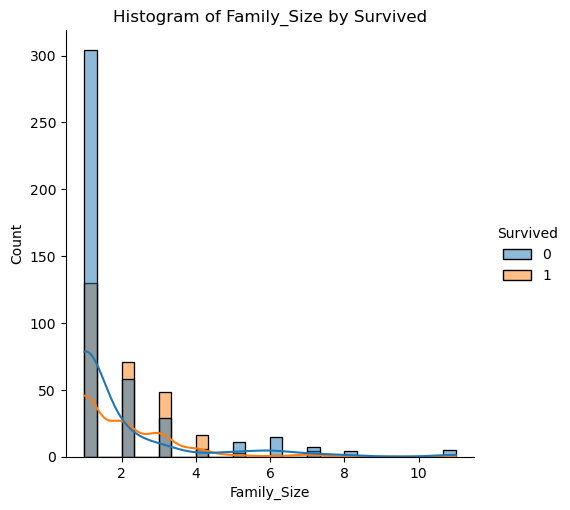

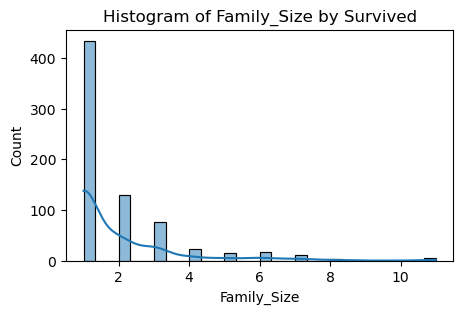

In [19]:
X_train_family_size = X_train[['Parch', 'SibSp']].copy()
X_train_family_size['Family_Size'] = X_train_family_size['Parch'] + X_train_family_size['SibSp'] + 1
visualize_feature(X_train_family_size, 'Family_Size', y_train)
visualize_feature(X_train_family_size, 'Family_Size')

#### Sex vs Is Alone 

* Non-linear survival rates observed for passengers traveling alone or with family, across genders.
* Females with family survived at significantly higher rate (0.78) than males with family (0.27)

In [20]:
X_train_isalone_pclass = X_train[['Parch', 'SibSp', 'Sex']].copy()
X_train_isalone_pclass['Is_Alone'] = ((X_train_family_size['Parch'] + X_train_family_size['SibSp'] + 1) == 1).astype(int)
comb_df = pd.concat([X_train_isalone_pclass, y_train], axis=1)
# Pivot table: Survival Rate by Is_Alone and Pclass
pivot = comb_df.pivot_table(
    index='Is_Alone',
    columns='Sex',
    values='Survived',
    aggfunc='mean'
)
pivot = pivot.rename_axis('Is_Alone').rename_axis('Sex', axis=1)
pivot


Sex,female,male
Is_Alone,,
0,0.717105,0.269841
1,0.782178,0.153153


### Feature Engineering

#### Feature Creation

In [21]:
def engineer_features(df):

    # Create Sex_Encoded feature
    df['Sex_Encoded'] = df['Sex'].map({'male': 0, 'female': 1})

    # Create Deck feature from CabinCabin
    df['Deck'] = df['Cabin'].str[0]

    # Fill missing Deck values with 'U' for Unknown
    df['Deck'] = df['Deck'].fillna('U')

    # Create Deck_Bin feature
    def bin_deck(deck):
        if deck in ['A', 'B', 'C']:
            return 'Upper'
        elif deck in ['D', 'E']:
            return 'Middle'
        elif deck in ['F', 'G', 'T']:
            return 'Rare'
        else:
            return 'Unknown Deck'
    df['Deck_Bin'] = df['Deck'].apply(bin_deck)

    # Create Title feature from Name
    def extract_title(name):
        title = name.split(',')[1].split('.')[0].strip()
        return title
    df['Title'] = df['Name'].apply(extract_title)

    # Create Surname feature from Name
    def extract_surname(name):
        surname = name.split(',')[0].strip()
        return surname
    df['Surname'] = df['Name'].apply(extract_surname)

    # Create Ticket Prefix and Number features from Ticket
    def extract_ticket_info(ticket):
        if pd.isnull(ticket):
            return None, None
        parts = ticket.split()
        prefix = parts[0] if len(parts) > 1 else ''
        number = parts[-1] if len(parts) > 1 else parts[0]
        return prefix, number
    df[['Ticket_Prefix', 'Ticket_Number']] = df['Ticket'].apply(lambda x: pd.Series(extract_ticket_info(x)))

    # Print non-numeric Ticket Numbers in training data with counts
    #non_numeric_ticket_numbers = df[~df['Ticket_Number'].str.isnumeric()]['Ticket_Number'].value_counts()
    #print("Non-numeric Ticket Numbers in training data:")
    #print(non_numeric_ticket_numbers)

    # Set 4 'LINE' Ticket Numbers to -1
    df.loc[df['Ticket_Number'].isin(['LINE']), 'Ticket_Number'] = -1

    # Create Family Size feature
    df['Family_Size'] = df['SibSp'] + df['Parch'] + 1
    def bin_family_size(size):
        if size <= 2:
            return f"{size}"
        elif size <= 4:
            return '3-4'
        else:
            return '5+'
    df['Family_Size_Bin'] = df['Family_Size'].apply(bin_family_size)

    # Create Is_Alone feature
    df['Is_Alone'] = (df['Family_Size'] == 1).astype(int)

    # Create Cabin_Count feature from Cabin
    df['Cabin_Count'] = df['Cabin'].apply(lambda x: len(x.split()) if pd.notnull(x) else 0)
    def bin_cabin_count(cabin_count):
        if cabin_count < 2:
            return cabin_count
        else:
            return 2
    df['Cabin_Count'] = df['Cabin_Count'].apply(bin_cabin_count)

    # Create Cabin Number feature
    # If feature contains multiple numbers, use the first one
    # If feature contains no numbers, set to NaN    
    df['Cabin_Number'] = df['Cabin'].str.extract(r'[A-Z](\d+)').astype('Int64')
    df['Cabin_Number'] = df['Cabin_Number'].fillna(0).astype(int)


    # Create Port or Starboard feature based on Cabin Number
    def cabin_side(cabin_number):
        if pd.isnull(cabin_number):
            return 'Unknown'
        return 'Starboard' if cabin_number % 2 == 0 else 'Port'
    df['Cabin_Side'] = df['Cabin_Number'].apply(cabin_side)

    # Create Cabin_Missing feature
    df['Cabin_Missing'] = df['Cabin'].isnull().astype(int)

    # Fill missing Cabin_Number values with 0
    df['Cabin_Number'] = df['Cabin_Number'].fillna(0).astype(int)

    # Create Age_Missing feature
    df['Age_Missing'] = df['Age'].isnull().astype(int)

    df['Is_Child'] = (df['Age'] < 10).astype(int)

    df['Is_Loner_P3_Male_Southampton'] = ((df['Is_Alone'] == 1) & (df['Pclass'] == 3) & (df['Sex']=='male') & (df['Embarked'] == 'S')).astype(int)

    return df


In [22]:
X_train = engineer_features(X_train)
X_test = engineer_features(X_test)
X_dev = engineer_features(X_dev)

#### Pipeline Imputers

* Mode and median calculations are used to impute the missing `Embarked` and `Age` values.
* Custom imputer classes are created so that the calculations are confined to only the training set/fold when evaluating models during Training and Cross Validation.

In [23]:
class AgeImputer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        df = pd.DataFrame(X).copy()
        # compute medians on training fold only
        self.pclass_title_median_ = (
            df.groupby(['Pclass','Title'])['Age']
              .median()
              .rename('median')
              .reset_index()
        )
        self.sex_median_ = (
            df.groupby('Sex')['Age']
              .median()
              .rename('median')
              .reset_index()
        )
        return self

    def transform(self, X):
        df = pd.DataFrame(X).copy()

        # helper to look up from pclass_title_median_
        def fill_pt(row):
            if pd.notna(row['Age']):
                return row['Age']
            mask = (
                (self.pclass_title_median_['Pclass']==row['Pclass']) &
                (self.pclass_title_median_['Title']==row['Title'])
            )
            val = self.pclass_title_median_[mask]['median']
            return float(val.iloc[0]) if not val.empty else row['Age']

        df['Age'] = df.apply(fill_pt, axis=1)

        # fallback to sex median
        def fill_sex(row):
            if pd.notna(row['Age']):
                return row['Age']
            mask = self.sex_median_['Sex']==row['Sex']
            return float(self.sex_median_[mask]['median'].iloc[0])
        df['Age'] = df.apply(fill_sex, axis=1)

        return df #[['Age']]

class AgeBinner(BaseEstimator, TransformerMixin):
    def __init__(self, bins, labels=None, drop_cols=None, right=True):
        """
        bins : list of edges, e.g. [0, 10, 17, 35, 55, np.inf]
        labels : list of labels of length len(bins)-1
        right : whether intervals include the right edge
        """
        self.bins = bins
        self.labels = labels
        self.right = right
        self.drop_cols = drop_cols

    def fit(self, X, y=None):
        # nothing to learn
        return self

    def transform(self, X):
        df = pd.DataFrame(X).copy()
        # apply pd.cut to the 'Age' column
        df['Age_Bin'] = pd.cut(
            df['Age'],
            bins=self.bins,
            labels=self.labels,
            right=self.right
        )
        if self.drop_cols is not None:
            # Drop specified columns to prevent them from being OHEC'd later
            df.drop(columns=self.drop_cols, inplace=True)
        return df

class EmbarkedImputer(BaseEstimator, TransformerMixin):
    def __init__(self):
        # no hyper‐parameters here
        pass

    def fit(self, X, y=None):
        """
        X: array‐like or DataFrame with columns ['Pclass','Embarked']
        """
        df = pd.DataFrame(X, columns=['Pclass','Embarked'])
        # compute the mode of Embarked for each Pclass
        # .mode() returns a Series (possibly multiple modes), so take the first [0]
        self.pclass_mode_ = (
            df
            .dropna(subset=['Embarked'])
            .groupby('Pclass')['Embarked']
            .agg(lambda s: s.mode().iloc[0])
            .to_dict()
        )
        return self

    def transform(self, X):
        df = pd.DataFrame(X, columns=['Pclass','Embarked']).copy()

        def _fill(row):
            if pd.notna(row['Embarked']):
                return row['Embarked']
            # lookup the Pclass‐mode, or fall back to overall mode
            return self.pclass_mode_.get(row['Pclass'],
                                        max(self.pclass_mode_.values(),
                                            key=lambda v: list(self.pclass_mode_.values()).count(v))
                                       )

        df['Embarked'] = df.apply(_fill, axis=1)
        return df

class TicketFrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.ticket_counts_ = None

    def fit(self, X, y=None):
        X_df = self._ensure_dataframe(X, ['Ticket'])
        self.ticket_counts_ = X_df['Ticket'].value_counts().to_dict()
        return self

    def transform(self, X):
        X_df = self._ensure_dataframe(X, ['Ticket'])
        X_df['Ticket_Frequency'] = X_df['Ticket'].map(self.ticket_counts_).fillna(1)
        return X_df[['Fare', 'Ticket_Frequency']]

    def _ensure_dataframe(self, X, columns):
        if isinstance(X, pd.DataFrame):
            return X
        return pd.DataFrame(X, columns=columns)
    
class FarePerPersonTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        self.is_fitted_ = True  # Flag to indicate to framework that this transformer is fitted (needs at least one attr ending with '_')
        return self

    def transform(self, X):
        X_df = self._ensure_dataframe(X, ['Fare', 'Ticket_Frequency'])
        X_df['Fare_Per_Person'] = np.log1p(X_df['Fare']) / X_df['Ticket_Frequency'].replace(0, 1)
        return X_df[['Fare_Per_Person', 'Ticket_Frequency']]

    def _ensure_dataframe(self, X, columns):
        if isinstance(X, pd.DataFrame):
            return X
        return pd.DataFrame(X, columns=columns)
    
class TargetEncoderWrapper(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None):
        self.columns = columns
        self.encoder_ = TargetEncoder(cols=columns)
        
    def fit(self, X, y):
        self.encoder_.fit(X, y)
        return self

    def transform(self, X):
        return self.encoder_.transform(X)   


In [24]:
exclusion_features = ['Name', 'Cabin', 'PassengerId', 'Ticket_Number']
meaningful_features = [feature for feature in X_train.columns.tolist() if feature not in exclusion_features]
print(f"Meaningful features: {meaningful_features}")

Meaningful features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked', 'Sex_Encoded', 'Deck', 'Deck_Bin', 'Title', 'Surname', 'Ticket_Prefix', 'Family_Size', 'Family_Size_Bin', 'Is_Alone', 'Cabin_Count', 'Cabin_Number', 'Cabin_Side', 'Cabin_Missing', 'Age_Missing', 'Is_Child', 'Is_Loner_P3_Male_Southampton']


### Model Development

In [25]:
def get_feature_names_from_preprocessor(preprocessor, selected_features):
    """Extract feature names after preprocessing."""
    feature_names = []
    
    for name, transformer, features in preprocessor.transformers_:
        if name == 'scaler' or name == 'passthrough' or name == 'loner_p3_male_southampton':
            feature_names.extend(features)
        elif name == 'fpp':
            feature_names.extend(['Fare_Per_Person', 'Ticket_Frequency'])
        elif name == 'loner_p3_male_southampton_young_adult_pipeline':
            feature_names.extend(['Is_Loner_P3_Male_Southampton_Young_Adult'])
        elif name == 'onehot':
            if hasattr(transformer, 'get_feature_names_out'):
                ohe_names = transformer.get_feature_names_out(features)
                feature_names.extend(ohe_names)
            else:
                categories = []
                for i, feature in enumerate(features):
                    cats = transformer.categories_[i]
                    for cat in cats:
                        categories.append(f"{feature}_{cat}")
                feature_names.extend(categories)
        elif name == 'fare_log_ohe':
            if hasattr(transformer, 'named_steps'):
                ohe = transformer.named_steps.get('ohe', None)
                if ohe is not None and hasattr(ohe, 'get_feature_names_out'):
                    ohe_names = ohe.get_feature_names_out(features)
                    feature_names.extend(ohe_names)
                else:
                    categories = ohe.categories_ if ohe is not None else []
                    for i, feature in enumerate(features):
                        for cat in categories[i]:
                            feature_names.append(f"{feature}_{cat}")
            else:
                feature_names.extend(features)
        elif name == 'age_ohe':
            if hasattr(transformer, 'named_steps'):
                ohe = transformer.named_steps.get('ohe_age', None)
                if ohe is not None and hasattr(ohe, 'get_feature_names_out'):
                    ohe_names = ohe.get_feature_names_out()
                    feature_names.extend(ohe_names)
                else:
                    categories = ohe.categories_ if ohe is not None else []
                    for i, feature in enumerate(features):
                        for cat in categories[i]:
                            feature_names.append(f"{feature}_{cat}")
            else:
                feature_names.extend(features)
            # ohe = transformer.named_steps.get('ohe_age', None)
            # categories = ohe.categories_[0] if ohe is not None else []
            # for cat in categories:
            #     feature_names.append(f"Age_Bin_{cat}")
        elif name == 'pclass_embarked_ohe' or name == 'pclass_sex_ohe':
            # This pipeline outputs one-hot encoded Pclass_Embarked
            if hasattr(transformer, 'named_steps'):
                ohe = transformer.named_steps.get('ohe_embarked', None)
                if ohe is not None and hasattr(ohe, 'get_feature_names_out'):
                    ohe_names = ohe.get_feature_names_out() # Intentionally pass None to default to ohe.feature_names_in_
                    feature_names.extend(ohe_names)
                else:
                    categories = ohe.categories_ if ohe is not None else []
                    for i, feature in enumerate(features):
                        for cat in categories[i]:
                            feature_names.append(f"{feature}_{cat}")
            else:
                feature_names.extend(features)
        elif name == 'p3_male_embarked_age_pipeline' or name == 'pclass_isalone_ohe':
            ohe = transformer.named_steps.get('ohe', None)
            if ohe is not None and hasattr(ohe, 'get_feature_names_out'):
                ohe_names = ohe.get_feature_names_out() # Intentionally pass None to default to ohe.feature_names_in_
                feature_names.extend(ohe_names)
            else:
                categories = ohe.categories_ if ohe is not None else []
                for i, feature in enumerate(features):
                    for cat in categories[i]:
                        feature_names.append(f"{feature}_{cat}")
    return feature_names


In [26]:
def deduplicate_df_majority_label(df, target='target'):
    duplicates = df.duplicated(keep=False)
    if duplicates.any():
        print(f"⚠️ Found {duplicates.sum()} duplicate rows in the training set after preprocessing.")
    else:
        print("No duplicate rows found in the training set after preprocessing.")
    feature_columns = list(df.columns[:-1])  
    def resolve_group(group):
        majority_target = group[target].mode().iloc[0]
        return pd.Series({target: majority_target})
    
    resolved_df = (df.groupby(feature_columns, observed=True)
                    .apply(resolve_group, include_groups=False)
                    .reset_index())
    print(f"Resolved duplicates: {len(resolved_df)} unique rows after deduplication.")
    return resolved_df

In [27]:
class DupFreeClassifier(BaseEstimator, ClassifierMixin):
    """
    Collapses duplicate rows in the training set and resolves conflicts by taking the majority class.
    This is useful to prevent information leakage from the holdout set during cross-validation.

    Assumes the base_estimator supports the sample_weight parameter.
    """
    def __init__(self, base_estimator):
        self.base_estimator = base_estimator

    def __getstate__(self):
        """Support for pickling"""
        state = self.__dict__.copy()
        return state
    
    def __setstate__(self, state):
        """Support for unpickling"""
        self.__dict__.update(state) 

    def get_params(self, deep=True):
        """Get parameters for this estimator and the wrapped estimator."""
        params = super().get_params(deep=False)
        if deep and hasattr(self, 'base_estimator'):
            base_params = self.base_estimator.get_params(deep=True)
            # Prefix base estimator parameters
            for key, value in base_params.items():
                params[f'base_estimator__{key}'] = value
        return params
    
    def set_params(self, **params):
        """Set parameters for this estimator and the wrapped estimator."""
        # Separate parameters for this wrapper vs the base estimator
        wrapper_params = {}
        base_params = {}
        
        for key, value in params.items():
            if key.startswith('base_estimator__'):
                # Remove prefix and set on base estimator
                base_key = key[len('base_estimator__'):]
                base_params[base_key] = value
            else:
                # Set on this wrapper
                wrapper_params[key] = value
        
        # Set base estimator parameters
        if base_params and hasattr(self, 'base_estimator'):
            self.base_estimator.set_params(**base_params)
        
        # Set wrapper parameters
        super().set_params(**wrapper_params)
        return self     
        
    def fit(self, X, y, **fit_params):
        #print(f"Fitting {self.__class__.__name__}...")
        try:
            if hasattr(X, 'toarray'):
                X_dense = X.toarray()
            else:
                X_dense = X

            # Mark as fitted for sklearn
            self.fitted_ = True  # Add this line

            df = pd.DataFrame(X_dense).copy()
            y_arr = np.asarray(y).ravel() 
            df['target'] = y_arr

            dedupe = fit_params.pop('dedupe', True)
            if  dedupe == True:
                print("Dedupe flag is set. Checking for duplicates in the training set...")

                # TODO If needed, use a more robust method than majority label to resolve duplicates
                df = deduplicate_df_majority_label(df)
            else:
                print("Deduplication deactivated. No deduplication performed.")
            feature_columns = list(df.columns[:-1])
            X_clean = df[feature_columns].copy()
            y_clean = df['target'].values

            print(f"Saving clean training set for later use... ({len(X_clean)} rows, {len(feature_columns)} features)")
            self.train_X_clean_ = X_clean.copy()

            self.estimator_ = clone(self.base_estimator)
            self.estimator_.fit(X_clean, y_clean, **fit_params)
            return self
        except Exception as e:
            print(f"Error during fitting {self.__class__.__name__}: {e}")
            raise

    def predict(self, X):
        print(f"Saving clean predicted set for later use... ({X.shape[0]} rows)")
        self.predicted_X_clean = X.copy()
        return self.estimator_.predict(X)

    def predict_proba(self, X):
        print(f"Saving clean predicted set for later use... ({X.shape[0]} rows)")
        self.predicted_X_clean = X.copy()
        return self.estimator_.predict_proba(X)

    def __getattr__(self, name):
        try:
            #print(f"Accessing attribute '{name}' of {type(self).__name__}")
            if 'estimator_' in self.__dict__:
                retval = getattr(self.estimator_, name)
                #print(f"Returning attribute '{name}' from estimator: {retval}")
                return retval
            elif 'base_estimator' in self.__dict__:
                retval = getattr(self.base_estimator, name)
                #print(f"Returning attribute '{name}' from base_estimator: {retval}")
                return retval
            else:
                #print(f"Attribute '{name}' not found in {type(self).__name__} or its base_estimator.")
                raise AttributeError(f"'{type(self).__name__}' object has no attribute '{name}'")
        except Exception as e:
            #print(f"Error accessing attribute '{name}': {e}")
            raise e

In [28]:
def evaluate_on_deduplicated_data(pipeline, X, y, selected_features, threshold=None):
    print("\n" + "="*50)
    print("EVALUATION ON DEDUPLICATED DATA")
    print("="*50)

    # Combine X and y into a DataFrame
    df = pd.DataFrame(X[selected_features]).copy()
    df['y_true'] = y

    # Deduplicate by feature columns, resolving conflicts by taking mode of y
    grouped = df.groupby(selected_features, sort=False)['y_true'].agg(lambda x: x.mode().iloc[0])
    X_dedup = grouped.index.to_frame(index=False).reset_index(drop=True)
    y_dedup = grouped.reset_index(drop=True)

    print(f"\nOriginal data: {len(X)} rows.")
    print(f"Deduplicated data: {len(X_dedup)} unique rows after deduplication.")

    # Predict using the pipeline
    y_pred_proba = pipeline.predict_proba(X_dedup)[:, 1]
    if threshold is not None:
        mlflow.log_param("proba_threshold", threshold)
        print(f"Using threshold: {threshold:.3f}")
        y_pred = (y_pred_proba >= threshold).astype(int)
    else:
        y_pred = pipeline.predict(X_dedup)

    print(f"\nDetailed Classification Report:")
    print(classification_report(y_dedup, y_pred, target_names=['Not Survived', 'Survived'], zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(y_dedup, y_pred, normalize='true')
    cm_counts = confusion_matrix(y_dedup, y_pred)
    mlflow.log_metric("cm_false_positive_pct", cm[0, 1])
    mlflow.log_metric("cm_false_negative_pct", cm[1, 0])

    # Annotate with both percent and count
    annot = np.empty_like(cm).astype(str)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f"{cm[i, j]:.2%}\n({cm_counts[i, j]})"

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', cbar=False,
                xticklabels=['Not Survived', 'Survived'],
                yticklabels=['Not Survived', 'Survived'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix\n(Percent, Count)')
    plt.show()

    # Compute metrics
    metrics = {
        'log_loss': log_loss(y_dedup, y_pred_proba),
        'roc_auc': roc_auc_score(y_dedup, y_pred_proba),
        'pr_auc': average_precision_score(y_dedup, y_pred_proba),
        'f1': f1_score(y_dedup, y_pred, average='macro', zero_division=0),
        'precision': precision_score(y_dedup, y_pred, average='macro', zero_division=0),
        'recall': recall_score(y_dedup, y_pred, average='macro', zero_division=0),
        'accuracy': accuracy_score(y_dedup, y_pred),
    }

    mlflow.log_metrics(metrics)

    print("\nModel Scores:")
    print(f"Log Loss: {metrics['log_loss']:.4f}")
    print(f"ROC AUC: {metrics['roc_auc']:.4f}")
    print(f"PR AUC: {metrics['pr_auc']:.4f}")
    print(f"F1 Score: {metrics['f1']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    print(f"Accuracy: {metrics['accuracy']:.4f}")

    ################## ROC Curve + ROC AUC
    fpr, tpr, thresholds = roc_curve(y_dedup, y_pred_proba)
    auc = roc_auc_score(y_dedup, y_pred_proba)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.3f})')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend()
    plt.grid(True)
    plt.show()

    ################## PR Curve + PR AUC
    precision, recall, thresholds = precision_recall_curve(y_dedup, y_pred_proba)
    avg_precision = average_precision_score(y_dedup, y_pred_proba)

    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, label=f'PR Curve (AP = {avg_precision:.3f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall (PR) Curve')
    plt.grid(True)
    plt.legend()
    plt.show()

    precision, recall, thresholds = precision_recall_curve(y_dedup, y_pred_proba)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)  # avoid div-by-zero
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]

    print(f"Best threshold for F1 score: {best_threshold:.3f}")
    print(f"Max F1 score: {f1_scores[best_idx]:.3f}")

    return metrics, pipeline.named_steps['classifier'].predicted_X_clean, y_dedup, y_pred, y_pred_proba

#### Training Set Evaluation

In [29]:
#mlflow.set_tracking_uri('http://ec2-3-22-170-33.us-east-2.compute.amazonaws.com:5000/')
mlflow.set_tracking_uri('http://localhost:5000/')
mlflow.set_experiment('titanic_ml_from_disaster__abridged')
ohe_features = ['Family_Size_Bin', 'Deck_Bin'] #, 'Cabin_Side', '', 'Family_SizeDeck_Bin_Bin']
selected_features = ['Is_Loner_P3_Male_Southampton', 'Is_Alone', 'Ticket', 'Cabin_Count', 'Pclass', 'Sex', 'Age', 'Fare', 'Title', 'Embarked'] + ohe_features #+ ['Pclass', 'Cabin_Count', 'Title', 'Embarked', 'Fare', 'Age'] 


PREPROCESSING AND TRAINING
Dedupe flag is set. Checking for duplicates in the training set...
⚠️ Found 267 duplicate rows in the training set after preprocessing.
Resolved duplicates: 498 unique rows after deduplication.
Saving clean training set for later use... (498 rows, 92 features)

Preprocessor generated the following 92 features:
* Fare_Per_Person
* Ticket_Frequency
* Pclass_Embarked_1_Q
* Pclass_Embarked_1_S
* Pclass_Embarked_2_C
* Pclass_Embarked_2_Q
* Pclass_Embarked_2_S
* Pclass_Embarked_3_C
* Pclass_Embarked_3_Q
* Pclass_Embarked_3_S
* Pclass_Sex_1_male
* Pclass_Sex_2_female
* Pclass_Sex_2_male
* Pclass_Sex_3_female
* Pclass_Sex_3_male
* Sex_IsAlone_female_1
* Sex_IsAlone_male_0
* Sex_IsAlone_male_1
* Age_Bin_Middle_Aged
* Age_Bin_Senior
* Age_Bin_Teen
* Age_Bin_Young_Adult
* Class_Sex_Embkd_Age_1_female_C_Senior
* Class_Sex_Embkd_Age_1_female_C_Teen
* Class_Sex_Embkd_Age_1_female_C_Young_Adult
* Class_Sex_Embkd_Age_1_female_Q_Young_Adult
* Class_Sex_Embkd_Age_1_female_S_M

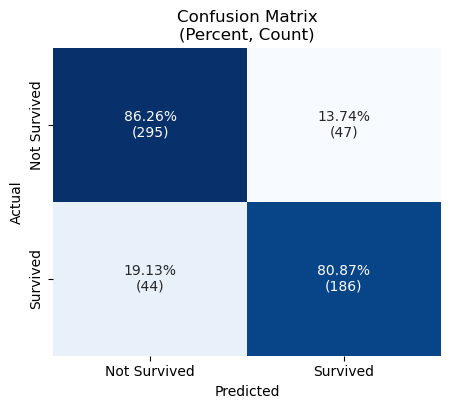


Model Scores:
Log Loss: 0.3832
ROC AUC: 0.8901
PR AUC: 0.8799
F1 Score: 0.8349
Precision: 0.8342
Recall: 0.8356
Accuracy: 0.8409


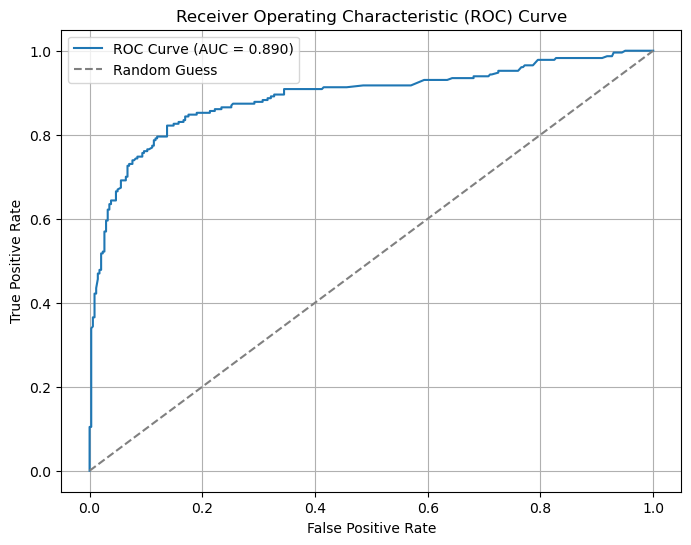

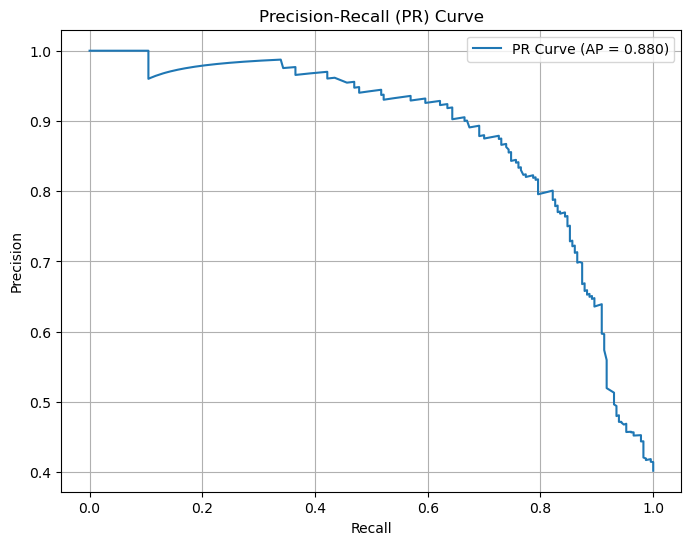

Best threshold for F1 score: 0.465
Max F1 score: 0.811

Non-Zero Coefficients:
                                            Coefficient
Class_Sex_Embkd_Age_2_male_S_Child             1.381789
Family_Size_Bin_3-4                            1.329614
Sex_IsAlone_female_1                           1.076774
Class_Sex_Embkd_Age_3_female_Q_Teen            0.899858
Class_Sex_Embkd_Age_1_female_C_Young_Adult     0.886470
...                                                 ...
Class_Sex_Embkd_Age_3_female_S_Middle_Aged    -0.918918
Pclass_Sex_2_male                             -0.920085
Age_Bin_Senior                                -0.937481
Sex_IsAlone_male_1                            -1.132127
Sex_IsAlone_male_0                            -1.274124

[92 rows x 1 columns]
🏃 View run monumental-cow-961 at: http://localhost:5000/#/experiments/345754476741573639/runs/5b4f641c37af4d45a8e80bd89d4cfc08
🧪 View experiment at: http://localhost:5000/#/experiments/345754476741573639


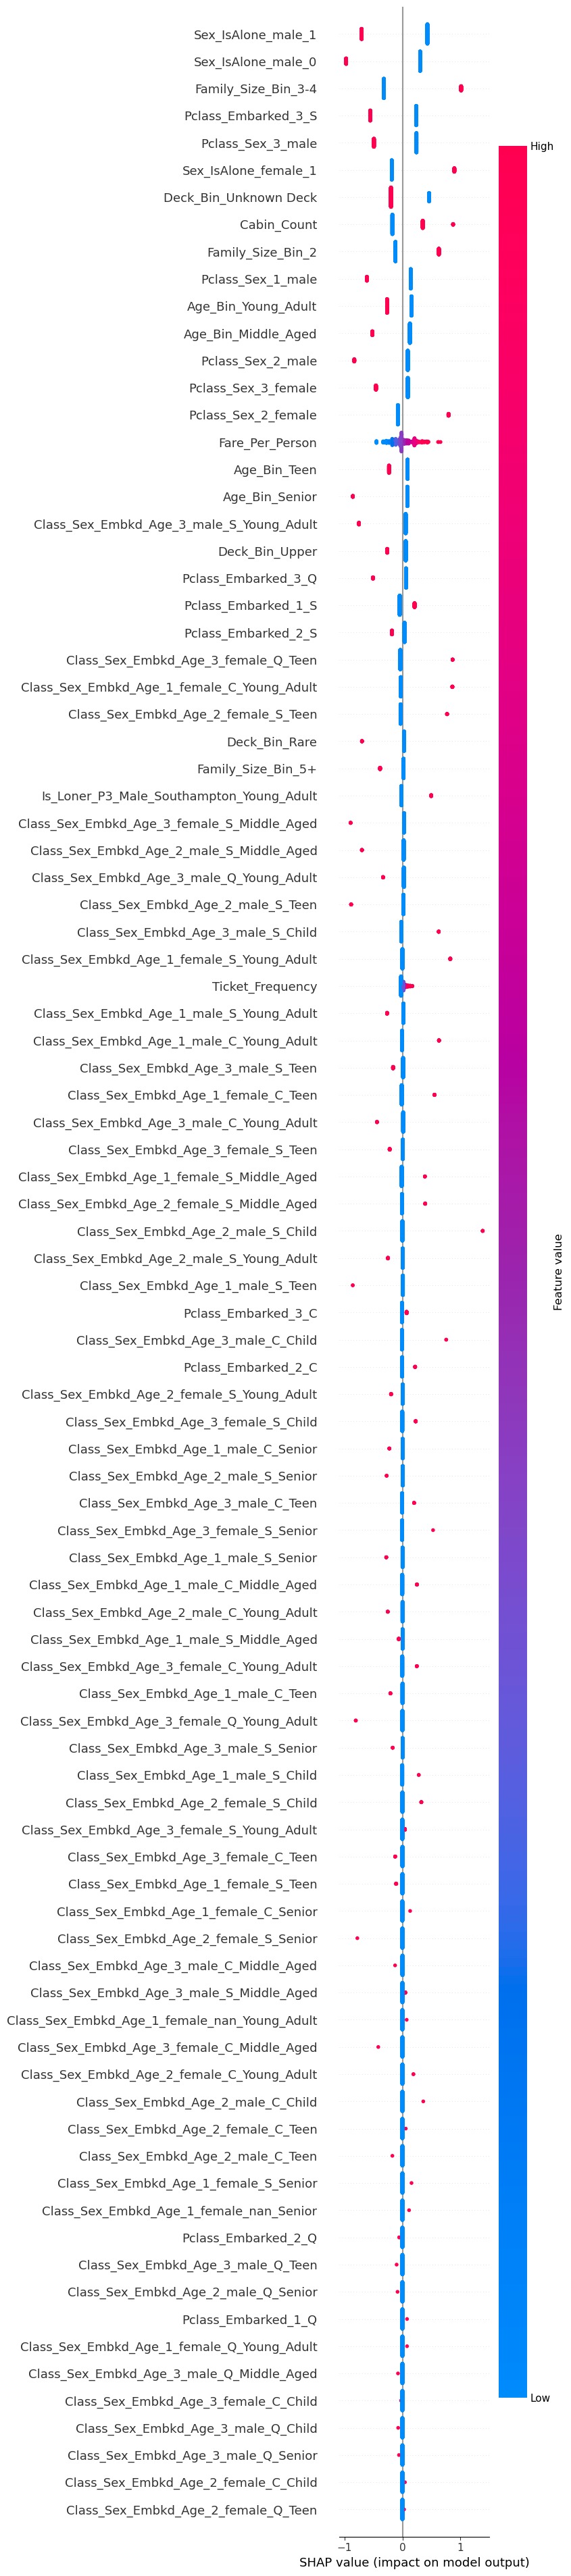

In [ ]:
with mlflow.start_run():
    mlflow.set_tag("dataset", "X_train")

    print("\n" + "="*50)
    print("PREPROCESSING AND TRAINING")
    print("="*50)

    ###### Create reusable preprocessor that is fit only prior to Training and CV evaluations
    num_fare_bins = 4   # Included in hyperparameter search
    mlflow.log_param("num_fare_bins", num_fare_bins)
    fare_bin_ohe_pipeline = Pipeline([
        ('log1p', FunctionTransformer(np.log1p, validate=False)),
        ('bins', KBinsDiscretizer(
            n_bins=num_fare_bins,
            encode='ordinal',
            strategy='quantile'
        )),
        ('ohe', OneHotEncoder(handle_unknown='ignore', drop='first'))
    ])

    fare_enrichment_pipeline = Pipeline([
        ('ticket_freq', TicketFrequencyEncoder()),
        ('fare_per_person', FarePerPersonTransformer()),
        ('scaler', StandardScaler())
    ])

    def create_pclass_embarked_feature(X):
        df = pd.DataFrame(X, columns=['Pclass', 'Embarked'])
        df['Pclass_Embarked'] = df['Pclass'].astype(str) + '_' + df['Embarked'].astype(str)
        return df[['Pclass_Embarked']]
    pclass_embarked_pipeline = Pipeline([
        ('impute_embarked', EmbarkedImputer()),
        ('create_pclass_embarked', FunctionTransformer(create_pclass_embarked_feature, validate=False)),
        ('ohe_embarked',    OneHotEncoder(handle_unknown='ignore', drop='first'))
    ])

    def create_pclass_sex_feature(X):
        df = pd.DataFrame(X, columns=['Pclass', 'Sex'])
        df['Pclass_Sex'] = df['Pclass'].astype(str) + '_' + df['Sex'].astype(str)
        return df[['Pclass_Sex']]
    pclass_sex_pipeline = Pipeline([
        ('create_pclass_sex', FunctionTransformer(create_pclass_sex_feature, validate=False)),
        ('ohe_embarked',    OneHotEncoder(handle_unknown='ignore', drop='first'))
    ])

    def create_sex_isalone_feature(X):
        df = pd.DataFrame(X, columns=['Sex', 'Is_Alone'])
        df['Sex_IsAlone'] = df['Sex'].astype(str) + '_' + df['Is_Alone'].astype(str)
        return df[['Sex_IsAlone']]
    sex_isalone_pipeline = Pipeline([
        ('create_sex_isalone', FunctionTransformer(create_sex_isalone_feature, validate=False)),
        ('ohe', OneHotEncoder(handle_unknown='ignore', drop='first'))
    ])

    bins = [0, 10, 25, 40, 55, 100]
    mlflow.log_param("age_bins", bins)
    labels = ['Child', 'Teen', 'Young_Adult', 'Middle_Aged', 'Senior']
    age_pipeline_cols = ['Pclass', 'Title', 'Sex', 'Age']
    age_pipeline = Pipeline([
        ('impute_age', AgeImputer()),  
        ('bin_age', AgeBinner(bins=bins, labels=labels, drop_cols=age_pipeline_cols)),
        ('ohe_age', OneHotEncoder(handle_unknown='ignore', drop='first'))
    ])
    
    def create_pclass_sex_embarked_age_bin_feature(X):
        df = pd.DataFrame(X, columns=['Pclass', 'Sex', 'Embarked', 'Age_Bin'])
        df['Class_Sex_Embkd_Age'] = df['Pclass'].astype(str) + '_' + df['Sex'].astype(str) + '_' + df['Embarked'].astype(str) + '_' + df['Age_Bin'].astype(str) 
        return df[['Class_Sex_Embkd_Age']] 
    p3_male_embarked_age_pipeline = Pipeline([
        ('impute_age', AgeImputer()),  
        ('bin_age',    AgeBinner(bins=bins, labels=labels, drop_cols=['Age', 'Title'])),
        ('create_pclass_sex_embarked_age_bin', FunctionTransformer(create_pclass_sex_embarked_age_bin_feature, validate=False)),
        ('ohe', OneHotEncoder(handle_unknown='ignore', drop='first'))
    ])


    loner_pipeline = Pipeline([
        ('select_loner', FunctionTransformer(
            lambda df: pd.DataFrame(df['Is_Loner_P3_Male_Southampton'], columns=[]),
            validate=False
        ))
    ])
    combined_feature_union = FeatureUnion([
        ('loner', loner_pipeline),
        ('age_pipeline', age_pipeline)
    ])
    def create_loner_p3_male_southampton_young_adult_feature(X):
        if hasattr(X, 'toarray'):
            X_dense = X.toarray()  # Convert sparse matrix to dense
        elif isinstance(X, np.ndarray):
            X_dense = X
        else:
            X_dense = np.array(X)
        expected_cols = ['Is_Loner_P3_Male_Southampton', 'Age_Bin_Middle_Aged', 'Age_Bin_Senior', 'Age_Bin_Teen', 'Age_Bin_Young_Adult']
        df = pd.DataFrame(X_dense, columns=expected_cols[:X_dense.shape[1]])
        df['Is_Loner_P3_Male_Southampton_Young_Adult'] = ((df['Is_Loner_P3_Male_Southampton'] == 1) & (df['Age_Bin_Young_Adult'] == 1)).astype(int)
        return df[['Is_Loner_P3_Male_Southampton_Young_Adult']] 
    loner_p3_male_southampton_young_adult_pipeline = Pipeline([
        ('combine_features', combined_feature_union),
        ('create_interaction', FunctionTransformer(create_loner_p3_male_southampton_young_adult_feature, validate=False))
    ])

    preprocessor = ColumnTransformer([
        ('fpp', fare_enrichment_pipeline, ['Ticket', 'Fare']),
        ('pclass_embarked_ohe', pclass_embarked_pipeline, ['Pclass', 'Embarked']),
        ('pclass_sex_ohe', pclass_sex_pipeline, ['Pclass', 'Sex']),
        ('pclass_isalone_ohe', sex_isalone_pipeline, ['Sex', 'Is_Alone']),
        ('age_ohe', age_pipeline, age_pipeline_cols),
        ('p3_male_embarked_age_pipeline', p3_male_embarked_age_pipeline, age_pipeline_cols + ['Embarked']),
        ('loner_p3_male_southampton_young_adult_pipeline', loner_p3_male_southampton_young_adult_pipeline, age_pipeline_cols + ['Is_Loner_P3_Male_Southampton']),
        ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'), ohe_features),
        ('scaler', StandardScaler(), ['Cabin_Count'])
    ])

    # Default Logistic Regression parameters
    default_model_params = {
        'C': 1, 
        'class_weight': 'balanced', 
        'fit_intercept': True, 
        'max_iter': 100, 
        'penalty': 'l2', 
        'solver': 'liblinear'
    }

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', DupFreeClassifier(LogisticRegression(**default_model_params, random_state=42)))
    ])

    mlflow.log_param("model_type", pipeline.named_steps['classifier'].__class__.__name__)
    mlflow.log_params(default_model_params)

    # Defer calibrating model probabilities to Stage 2 (CV) given Stage 1 focus on model bias optimization
    pipeline.fit(X_train[selected_features], y_train)

    # TODO Calculate VIF of generated features to minimize multicollinearity prior to evaluating model performance

    feature_names_after_preprocessing = get_feature_names_from_preprocessor(
        pipeline.named_steps['preprocessor'], 
        selected_features
    )

    print(f"\nPreprocessor generated the following {len(feature_names_after_preprocessing)} features:")
    for i, feat in enumerate(feature_names_after_preprocessing):
        print(f"* {feat}")
        mlflow.log_param(f"feature_{i}", feat)

    _, X_predicted_csr_matrix, y_true, y_pred, y_pred_proba = evaluate_on_deduplicated_data(pipeline, X_train, y_train, selected_features, threshold=0.465)
 
    print("\nNon-Zero Coefficients:")
    coef_df = pd.DataFrame(pipeline.named_steps['classifier'].coef_.T, index=feature_names_after_preprocessing, columns=['Coefficient'])
    non_zero_coefs = coef_df[coef_df['Coefficient'] != 0].sort_values(by='Coefficient', ascending=False)
    zero_coefs = coef_df[coef_df['Coefficient'] == 0]
    print(non_zero_coefs)

    if default_model_params['penalty'] == 'l1':
        print("\nZeroed-out Coefficients:")
        print(zero_coefs)

    X_train_processed = pipeline.named_steps['classifier'].train_X_clean_
    X_train_processed.columns = feature_names_after_preprocessing
    explainer = shap.LinearExplainer(pipeline.named_steps['classifier'], X_train_processed)
    shap_values = explainer.shap_values(X_train_processed)
    shap.summary_plot(shap_values, X_train_processed, plot_type="dot", show=False, max_display=len(X_train_processed.columns))

#### Training Set Prediction Mistake Analysis

* Confusion matrix shows model is able to classify 94% of negative class `Survived=0` but only 67% of positive class `Survived=1`.
* We take a closer look at the training samples where `Survived=1` to see what feature engineering we can introduce to help the model recognize survivors.

In [31]:
X_predicted_csr_matrix.shape, y_true.shape, y_pred.shape, y_pred_proba.shape

((572, 92), (572,), (572,), (572,))

In [32]:
# Filter y_train, y_pred, y_pred_proba to match X_train_processed
X_predicted = pd.DataFrame(X_predicted_csr_matrix.toarray(), columns=feature_names_after_preprocessing)
training_prediction_results_df = pd.concat([
    X_predicted.reset_index(drop=True),
    pd.Series(y_true, name='y_true'),
    pd.Series(y_pred, name='y_pred'),
    pd.Series(y_pred_proba, name='y_pred_proba')
], axis=1)

training_prediction_results_df['Mistake'] = training_prediction_results_df['y_true'] !=  training_prediction_results_df['y_pred']
training_prediction_results_df['Mistake_Prob'] = np.abs(training_prediction_results_df['y_pred_proba'] - training_prediction_results_df['y_true'])
survived_pred_results_df = training_prediction_results_df[training_prediction_results_df['y_true'] == 1]
perished_pred_results_df = training_prediction_results_df[training_prediction_results_df['y_true'] == 0]
print(f"Mistake Rate of Perished Passengers: {perished_pred_results_df['Mistake'].mean():.2%} ({perished_pred_results_df['Mistake'].sum()})")
print(f"Mistake Rate of Survived Passengers: {survived_pred_results_df['Mistake'].mean():.2%} ({survived_pred_results_df['Mistake'].sum()})")

Mistake Rate of Perished Passengers: 13.74% (47)
Mistake Rate of Survived Passengers: 19.13% (44)


##### Correct vs Mistake Feature Distribution Comparison

Large spike in high-log-loss mistakes suggests model has blind spot to survival subgroup(s).

C:\Users\pault\AppData\Local\Temp\ipykernel_10864\3235286830.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


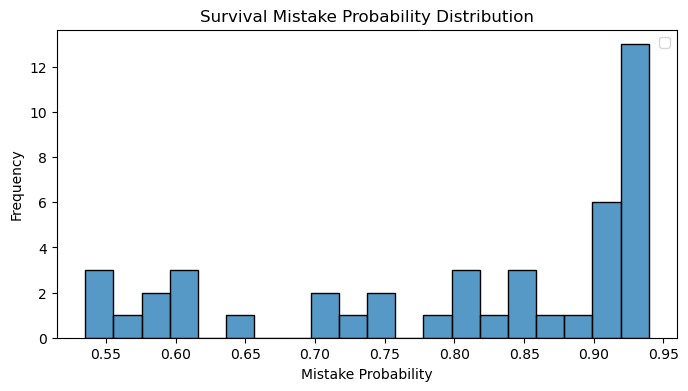

In [33]:
# Separate Mistakes from Correct Predictions for distribution comparison
survived_pred_results_df_mistakes = survived_pred_results_df[survived_pred_results_df['Mistake'] == True]
survived_pred_results_df_correct = survived_pred_results_df[survived_pred_results_df['Mistake'] == False]

# Probability Distribution of Mistaken Predictions of Survived Passengers
plt.figure(figsize=(8, 4))
sns.histplot(survived_pred_results_df_mistakes['Mistake_Prob'], bins=20)
plt.title('Survival Mistake Probability Distribution')
plt.xlabel('Mistake Probability')
plt.ylabel('Frequency')
plt.legend()
plt.show()

C:\Users\pault\AppData\Local\Temp\ipykernel_10864\4199816303.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


High-Confidence Mistakes: 19 (92.43%)


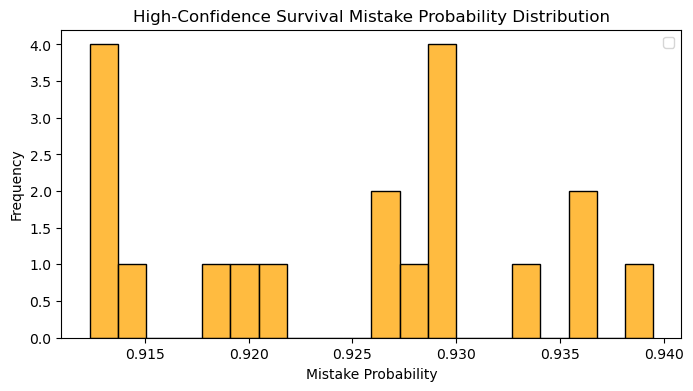

In [34]:
# Separating highest-confidence mistakes `Mistake_Prob > 0.85` and 
# comparing distribution to Correct predictions to see if any differences
high_confidence_mistakes = survived_pred_results_df_mistakes[survived_pred_results_df_mistakes['Mistake_Prob'] > 0.90]
print(f"High-Confidence Mistakes: {len(high_confidence_mistakes)} ({high_confidence_mistakes['Mistake_Prob'].mean():.2%})")

# Probability Distribution of High-Confidence Mistakes of Survived Passengers
plt.figure(figsize=(8, 4))
sns.histplot(high_confidence_mistakes['Mistake_Prob'], bins=20, color='orange')
plt.title('High-Confidence Survival Mistake Probability Distribution')
plt.xlabel('Mistake Probability')
plt.ylabel('Frequency')
plt.legend()
plt.show()

##### Feature Predictiveness of High-Confidence Mistakes

* A LogisticRegression model is trained with base features and `Mistake` as target in order to use coefficients to identify features that helped and hurt model predictiveness.
* Training sample contains only mistakes where `Mistake_Prob > 0.90` to identify features most predictive of _high-confidence_ mistakes.

In [54]:
X = survived_pred_results_df[(survived_pred_results_df['Mistake'] == False) | (survived_pred_results_df['Mistake_Prob'] > 0.90)]  # Filter out low-confidence mistakes
y = X['Mistake'].astype(int)
X = X.drop(columns=['Mistake', 'Mistake_Prob', 'y_pred', 'y_pred_proba', 'y_true'])
lr = LogisticRegression(
                C=1.0, 
                class_weight='balanced', 
                fit_intercept=True, 
                max_iter=100, 
                penalty='l2', 
                solver='liblinear', 
                random_state=42
            )
lr.fit(X, y)

print("\nLogistic Regression Coefficients for Mistake Prediction:")
mistake_coef_df = pd.DataFrame(lr.coef_.T, index=X.columns, columns=['Coefficient'])
mistake_coef_df.sort_values(by='Coefficient', ascending=False, inplace=True)
print(mistake_coef_df)


Logistic Regression Coefficients for Mistake Prediction:
                                          Coefficient
Sex_IsAlone_male_1                           2.217522
Pclass_Sex_3_male                            1.285531
Is_Loner_P3_Male_Southampton_Young_Adult     0.700757
Class_Sex_Embkd_Age_3_male_S_Young_Adult     0.700757
Pclass_Sex_2_male                            0.647984
...                                               ...
Pclass_Sex_2_female                         -0.948448
Pclass_Sex_3_female                         -0.997156
Cabin_Count                                 -1.111859
Sex_IsAlone_female_1                        -1.171066
Family_Size_Bin_3-4                         -1.203067

[92 rows x 1 columns]


#### Dev Set Evaluation

In [36]:
# # Perform hyperparameter tuning using CV within dev set
# with mlflow.start_run():
#     mlflow.set_tag("dataset", "X_dev")

#     mlflow.log_params(default_model_params)
#     mlflow.log_param("model_type", pipeline.named_steps['classifier'].__class__.__name__)
#     #mlflow.log_param("num_fare_bins", num_fare_bins)

#     print(f"\nEvaluating model with {len(feature_names_after_preprocessing)} features:")
#     for i, feat in enumerate(feature_names_after_preprocessing):
#         print(f"* {feat}")
#         mlflow.log_param(f"feature_{i}", feat)

#     # Reuse preprocessor and classifier
#     y_pred = pipeline.predict(X_dev[selected_features])
#     y_pred_proba = pipeline.predict_proba(X_dev[selected_features])[:, 1]

#     dev_logloss = log_loss(y_dev, pipeline.predict_proba(X_dev[selected_features]))
#     dev_rocauc = roc_auc_score(y_dev, y_pred_proba)
#     dev_prauc = average_precision_score(y_dev, y_pred_proba)
#     dev_acc  = accuracy_score(y_dev, y_pred)
#     dev_prec = precision_score(y_dev, y_pred, average='macro')
#     dev_rec  = recall_score(y_dev, y_pred, average='macro')
#     dev_f1   = f1_score(y_dev, y_pred, average='macro')
    
#     mlflow.log_metrics({ 
#         "log_loss": dev_logloss,
#         "roc_auc": dev_rocauc,
#         "pr_auc": dev_prauc,
#         "f1": dev_f1,
#         "accuracy": dev_acc,
#         "precision": dev_prec,
#         "recall": dev_rec
#     })

#     print("\nDev Set Scores:")
#     print("Dev Log Loss:", dev_logloss)
#     print("Dev ROC AUC:", dev_rocauc)
#     print("Dev PR AUC:", dev_prauc)
#     print("Dev F1:", dev_f1)
#     print("Dev Precision:", dev_prec)
#     print("Dev Recall   :", dev_rec)
#     print("Dev Accuracy :", dev_acc)
#     print()

#     # Diagnostic Outputs
#     X_dev_dense_processed = pipeline.named_steps['preprocessor'].transform(X_dev[selected_features]).toarray()
#     X_dev_processed = pd.DataFrame(X_dev_dense_processed, columns=feature_names_after_preprocessing)
#     print_diagnostics(pipeline.named_steps['classifier'], X_dev_processed, y_dev, y_pred, y_pred_proba, feature_names_after_preprocessing)   


#### Grid Search Cross-Validation Evaluation

In [37]:
# # Create function to evaluate distribution differences for each CV iteration
# def evaluate_cv_distribution_differences(X, y, cv_splitter, features):
#     significant_diffs = []
#     for train_idx, val_idx in cv_splitter.split(X, y):
#         X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]

#         significant_diffs.extend(statistical_distribution_tests(X_train, X_val, features))
#     print("Significant distribution differences found:")
#     for diff in significant_diffs:
#         print(diff)

In [38]:
# with mlflow.start_run():
#     mlflow.set_tag("dataset", "X_train_full")

#     print(f"\nEvaluating model with {len(feature_names_after_preprocessing)} features:")
#     for i, feat in enumerate(feature_names_after_preprocessing):
#         print(f"* {feat}")
#         mlflow.log_param(f"feature_{i}", feat)

#     param_grid = [
#         {
#             # use saga so we can also test ElasticNet
#             'classifier': [DupFreeClassifier(LogisticRegression(solver='saga'))],
#             'classifier__base_estimator__penalty':    ['l1', 'l2', 'elasticnet'],
#             'classifier__base_estimator__C':          [0.01, 0.1, 1, 10],
#             'classifier__base_estimator__l1_ratio':   [0.0, 0.5, 1.0], # only used when penalty='elasticnet'; ignored otherwise
#             'classifier__base_estimator__max_iter':   [100, 1000],
#             'classifier__base_estimator__class_weight':[None, 'balanced'],
#             'classifier__base_estimator__fit_intercept':[True, False],
#             #'preprocessor__fare_log_ohe__bins__n_bins': [3, 4, 5]
#         },
#         {
#             'classifier': [DupFreeClassifier(RandomForestClassifier())],
#             'classifier__base_estimator__n_estimators': [100, 200],
#             'classifier__base_estimator__max_depth': [None, 10],
#             'classifier__base_estimator__min_samples_split': [2, 5],
#             #'preprocessor__fare_log_ohe__bins__n_bins': [3, 4, 5]
#         },
#         {
#             'classifier': [DupFreeClassifier(GradientBoostingClassifier())],
#             'classifier__base_estimator__n_estimators': [100, 200],
#             'classifier__base_estimator__learning_rate': [0.05, 0.1],
#             'classifier__base_estimator__max_depth': [3, 5],
#             #'preprocessor__fare_log_ohe__bins__n_bins': [3, 4, 5]
#         },
#         {
#             'classifier': [DupFreeClassifier(SVC(probability=True))],
#             'classifier__base_estimator__C': [0.1, 1, 10],
#             'classifier__base_estimator__kernel': ['linear', 'rbf'],
#             'classifier__base_estimator__gamma': ['scale'],
#             #'preprocessor__fare_log_ohe__bins__n_bins': [3, 4, 5]
#         },
#         {
#             'classifier': [DupFreeClassifier(XGBClassifier(eval_metric='logloss'))],
#             'classifier__base_estimator__n_estimators':    [100, 200],
#             'classifier__base_estimator__max_depth':       [3, 5],
#             'classifier__base_estimator__learning_rate':   [0.05, 0.1],
#             'classifier__base_estimator__subsample':       [0.8, 1.0],
#             'classifier__base_estimator__colsample_bytree': [0.8, 1.0],
#             'classifier__base_estimator__reg_alpha':       [0, 0.1, 1],
#             'classifier__base_estimator__reg_lambda':      [1, 5, 10],
#             'classifier__base_estimator__gamma':           [0.0, 0.1, 1],
#             #'preprocessor__fare_log_ohe__bins__n_bins': [3, 4, 5]
#         },
#         {
#             'classifier': [DupFreeClassifier(LGBMClassifier())],
#             'classifier__base_estimator__n_estimators':       [100, 200],
#             'classifier__base_estimator__learning_rate':      [0.05, 0.1],
#             'classifier__base_estimator__boosting_type':      ['gbdt'],
#             'classifier__base_estimator__num_leaves':         [15, 31],
#             'classifier__base_estimator__lambda_l1':          [0.0, 0.5, 1.0],   
#             'classifier__base_estimator__lambda_l2':          [0.0, 1.0, 2.0],   
#             'classifier__base_estimator__min_gain_to_split':  [0.0, 0.01, 0.1],  
#             'classifier__base_estimator__min_data_in_leaf':   [10, 20, 30],     
#             'classifier__base_estimator__feature_fraction':   [0.7, 0.9, 1.0],   
#             'classifier__base_estimator__bagging_fraction':   [0.7, 0.9, 1.0],   
#             'classifier__base_estimator__bagging_freq':       [0, 1],
#             #'preprocessor__fare_log_ohe__bins__n_bins': [3, 4, 5]
#         }
#     ]

#     scoring_dict = {
#         'accuracy': 'accuracy',
#         'precision': 'precision_macro', 
#         'recall': 'recall_macro',
#         'f1': 'f1_macro',
#         'logloss': 'neg_log_loss'
#     }

#     cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
#     search = RandomizedSearchCV(
#         pipeline,
#         param_distributions=param_grid,
#         cv=cv,                    
#         scoring=scoring_dict,           
#         n_jobs=-1,
#         refit='logloss',  # after search, re‐fit on all train/dev
#         return_train_score=True,
#         n_iter=200,  # Adjust based on available time and resources 
#         verbose=1      
#     )

#     # Fit model, incorporating Age and Embarked sample weights
#     print("\nExecuting RandomizedSearchCV on X_train_full with deduplicated sample weights...")
#     search.fit(X_train_full[selected_features], y_train_full)
#     print("RandomizedSearchCV completed.")

#     pipeline = search.best_estimator_
#     # print("\nPipeline data type:")
#     # print(type(pipeline))  # Confirm the type of the pipeline object
#     # print(f"Pipeline steps: {pipeline.steps}")
    
#     # Extract results from RandomizedSearchCV
#     results_df = pd.DataFrame(search.cv_results_)

#     # See unique classifier types that were tried
#     print("\nClassifier types tested:")
#     print(results_df['param_classifier'].unique())

#     model_params = search.best_params_
#     print(f"\nBest Model Type: {pipeline.named_steps['classifier'].estimator_.__class__.__name__}")
#     print(f"\nBest Parameters: {model_params}")

#     # Trim each param in model_params to not exceed 500 characters
#     for key, value in model_params.items():
#         if isinstance(value, str) and len(value) > 500:
#             model_params[key] = value[:500]

#     mlflow.log_params(model_params)
#     mlflow.log_param("model_type", pipeline.named_steps['classifier'].estimator_.__class__.__name__)
#     #num_fare_bins = pipeline.named_steps['preprocessor'].named_transformers_['fare_log_ohe'].named_steps['bins'].n_bins
#     #mlflow.log_param("num_fare_bins", num_fare_bins)

#     mlflow.log_metric("best_cv_acc", search.best_score_)

#     best_idx = search.best_index_
#     cv_acc_mean = search.cv_results_[f'mean_test_accuracy'][best_idx]
#     cv_acc_std = search.cv_results_[f'std_test_accuracy'][best_idx]
#     cv_prec_mean = search.cv_results_[f'mean_test_precision'][best_idx]
#     cv_prec_std = search.cv_results_[f'std_test_precision'][best_idx]
#     cv_rec_mean = search.cv_results_[f'mean_test_recall'][best_idx]
#     cv_rec_std = search.cv_results_[f'std_test_recall'][best_idx]
#     cv_f1_mean = search.cv_results_[f'mean_test_f1'][best_idx]
#     cv_f1_std = search.cv_results_[f'std_test_f1'][best_idx]
#     cv_logloss_mean = np.nan #-search.cv_results_[f'mean_test_logloss'][best_idx]
#     cv_logloss_std = np.nan #search.cv_results_[f'std_test_logloss'][best_idx]

#     mlflow.log_metrics({
#         "accuracy": cv_acc_mean,
#         "precision": cv_prec_mean,
#         "recall": cv_rec_mean,
#         "f1": cv_f1_mean,
#         #"logloss": cv_logloss_mean
#     })

#     print("\nCV Scores:")
#     print("CV accuracy:", cv_acc_mean)
#     print("CV accuracy (std):", cv_acc_std)
#     print("CV precision:", cv_prec_mean)
#     print("CV precision (std):", cv_prec_std)
#     print("CV recall:", cv_rec_mean)
#     print("CV recall (std):", cv_rec_std)
#     print("CV F1:", cv_f1_mean)
#     print("CV F1 (std):", cv_f1_std)
#     # print("CV Log Loss:", cv_logloss_mean)
#     # print("CV Log Loss (std):", cv_logloss_std)
#     print()

#     # Generate predictions with the best model
#     y_pred = pipeline.predict(X_train_full[selected_features])
#     y_pred_proba = pipeline.predict_proba(X_train_full[selected_features])[:, 1]

#     # Diagnostic Outputs
#     X_train_full_dense_processed = pipeline.named_steps['preprocessor'].transform(X_train_full[selected_features]).toarray()
#     X_train_full_processed = pd.DataFrame(X_train_full_dense_processed, columns=feature_names_after_preprocessing)
#     print_diagnostics(pipeline.named_steps['classifier'], X_train_full_processed, y_train_full, y_pred, y_pred_proba, feature_names_after_preprocessing)  

#### Evaluation Summary

In [39]:
# # Create table summarizing evaluation scores across training, dev, cv, and holdout sets
# def create_evaluation_summary_table_and_plot():
#     """
#     Prints pre- and post-hyperparameter tuning bias/variance,
#     returns evaluation summary table, and plots evaluation metrics across all data splits.
#     """

#     # Create summary table
#     data = {
#         'Set': ['Training', 'Dev', 'Grid Search CV'],
#         'Log Loss': [training_logloss, dev_logloss, cv_logloss_mean],
#         'ROC AUC': [training_rocauc, dev_rocauc, np.nan],  # ROC AUC not computed for CV
#         'PR AUC': [training_prauc, dev_prauc, np.nan],  # PR AUC not computed for CV
#         'F1 Score': [training_f1, dev_f1, cv_f1_mean],
#         'Precision': [training_prec, dev_prec, cv_prec_mean],
#         'Recall': [training_rec, dev_rec, cv_rec_mean],
#         'Accuracy': [training_acc, dev_acc, cv_acc_mean],
#     }
#     summary_df = pd.DataFrame(data)

#     print("\nEvaluation Summary Table:")
#     print(summary_df)

#     # Bias/variance report
#     print(f"\nModel Metric Variance (train - holdout) Report:")
#     print(f"Log Loss Variance: {(training_logloss - dev_logloss):.4f}")
#     print(f"ROC AUC Variance: {(training_rocauc - dev_rocauc):.4f}")
#     print(f"PR AUC Variance: {(training_prauc - dev_prauc):.4f}")
#     print(f"F1 Score Variance: {(training_f1 - dev_f1):.4f}")
#     print(f"Precision Variance: {(training_prec - dev_prec):.4f}")
#     print(f"Recall Variance: {(training_rec - dev_rec):.4f}")
#     print(f"Accuracy Variance: {(training_acc - dev_acc):.4f}")

#     print()

#     # Plotting
#     plt.figure(figsize=(6, 4))
#     for metric in ['Log Loss', 'ROC AUC', 'PR AUC', 'F1 Score', 'Precision', 'Recall', 'Accuracy']:
#         plt.plot(summary_df['Set'], summary_df[metric], marker='o', label=metric)

#     plt.title(f'{pipeline.named_steps['classifier'].estimator_.__class__.__name__} Performance: Training vs Dev vs CV vs Holdout')
#     plt.ylabel('Score')
#     plt.xlabel('Evaluation Set')
#     plt.ylim(0.3, 0.87)
#     plt.grid(True)
#     plt.legend()
#     plt.tight_layout()
#     plt.show()


# create_evaluation_summary_table_and_plot()

### Submission File Generation

In [40]:
# Retrain on full training set and apply X_test sample weights
full_train_set = training_set_df.copy()
X_full_train_set = full_train_set.drop(columns=['Survived'])
X_full_train_set = engineer_features(X_full_train_set)
y_full_train_set = full_train_set['Survived']
print(X_full_train_set.shape, y_full_train_set.shape)

# TODO Resolve the issue with sample weights
#pipeline.fit(X_full_train_set[selected_features], y_full_train_set, classifier__dedupe=False, classifier__sample_weight=X_test_sample_weights)

(891, 28) (891,)


In [41]:
X_test.isnull().sum().loc[lambda x: x > 0]

Age       86
Fare       1
Cabin    327
dtype: int64

In [42]:
X_test[X_test['Fare'].isnull()]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,...,Family_Size,Family_Size_Bin,Is_Alone,Cabin_Count,Cabin_Number,Cabin_Side,Cabin_Missing,Age_Missing,Is_Child,Is_Loner_P3_Male_Southampton
152,1044,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,...,1,1,1,0,0,Starboard,1,0,0,1


In [43]:
X_test['Fare'] = X_test['Fare'].fillna(X_test.groupby(['Pclass', 'Embarked'])['Fare'].transform('median'))

In [44]:
X_test.isnull().sum().loc[lambda x: x > 0]

Age       86
Cabin    327
dtype: int64

In [45]:
X_test = engineer_features(X_test)

In [46]:
submission = pd.DataFrame({
    'PassengerId': X_test['PassengerId'],
    'Survived': pipeline.predict(X_test[selected_features])
})
timestamp = datetime.now().strftime('%Y%m%d-%H%M%S')
filename = f'./submission-{timestamp}.csv'
submission.to_csv(filename, index=False)

Saving clean predicted set for later use... (418 rows)


c:\Users\pault\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


-----------

In [47]:
import json
import re

def slugify(text):
    text = text.strip()
    text = re.sub(r'[^\w\s\-]', '', text)  # allow (), - and alphanumerics
    return re.sub(r'[\s]+', '-', text)

def extract_headings(ipynb_path):
    with open(ipynb_path, 'r', encoding='utf-8') as f:
        nb = json.load(f)

    toc_lines = [] # ["## Table of Contents\n"]
    for cell in nb['cells']:
        if cell['cell_type'] == 'markdown':
            for line in cell['source']:
                match = re.match(r'^(#{2,6})\s+(.*)', line)
                if match:
                    level = len(match.group(1)) - 1  # offset for nesting
                    title = match.group(2).strip()
                    anchor = slugify(title)
                    indent = '    ' * (level - 1)
                    toc_lines.append(f"{indent}1. [{title}](#{anchor})")

    return '\n'.join(toc_lines)

# Example usage:
toc = extract_headings("titanic_ml_from_disaster_abridged__paultongyoo.ipynb")
print(toc)

1. [Table of Contents](#Table-of-Contents)
1. [Project Summary](#Project-Summary)
    1. [What I Did](#What-I-Did)
    1. [What I Learned](#What-I-Learned)
    1. [Next Steps](#Next-Steps)
1. [Problem Context](#Problem-Context)
1. [Source Data](#Source-Data)
    1. [Data Dictionary](#Data-Dictionary)
    1. [Variable Notes](#Variable-Notes)
1. [Model Development Strategy](#Model-Development-Strategy)
    1. [Data Sets](#Data-Sets)
    1. [Five Stage Process](#Five-Stage-Process)
    1. [Metrics Strategy](#Metrics-Strategy)
1. [Implementation](#Implementation)
    1. [Descriptive Statistics](#Descriptive-Statistics)
    1. [Data Types](#Data-Types)
    1. [Missing Values Summary](#Missing-Values-Summary)
    1. [Visual Inspection Insights](#Visual-Inspection-Insights)
    1. [Exploratory Data Analysis](#Exploratory-Data-Analysis)
        1. [Survived (Target)](#Survived-Target)
        1. [Age](#Age)
        1. [Fare](#Fare)
        1. [Deck](#Deck)
        1. [Family Size](#Family-Size